In [ ]:
1. Write a Python script for Weather Data Analysis:
Problem Statement:
You have a CSV file named 'weather_data.csv' containing daily weather data for a city.

Date Temperature
(°C)

Humidity
(%)

Wind
Speed
(km/h)

Rainfall
(mm)
01-01-2025 15.2 80 10.5 0
02-01-2025 16.8 75 8 0
03-01-2025 14.5 85 12 1.2
04-01-2025 13 90 15.2 5.4
05-01-2025 17.6 70 7.4 0
06-01-2025 18.1 65 6 0
07-01-2025 16.2 78 9.1 0.5
08-01-2025 12.4 88 14.3 2.1
09-01-2025 13.8 83 11.5 0
10-01-2025 15.5 79 10 0
Perform the following tasks:
a. Check for missing values and handle them appropriately,
b. Calculate the average temperature for each month,
c. Visualize the monthly average temperature using a bar plot

Initial Data:
         Date  Temperature (°C)  Humidity (%)  Wind Speed (km/h)  \
0  01-01-2023         10.180861     87.706962          14.310666   
1  02-01-2023          0.519330     53.372085           0.086657   
2  03-01-2023          8.016772     75.718505          18.624254   
3  04-01-2023         14.990022     83.699179          15.768515   
4  05-01-2023          4.176964     79.137942          13.719805   

   Rainfall (mm)  
0       0.447501  
1       5.311329  
2       6.794113  
3       7.683554  
4       1.339057  

Missing Values:
Date                 0
Temperature (°C)     0
Humidity (%)         0
Wind Speed (km/h)    0
Rainfall (mm)        0
dtype: int64

Monthly Average Temperature:
Month
1    16.377740
2    15.688893
3    16.158118
4    11.948166
Name: Temperature (°C), dtype: float64


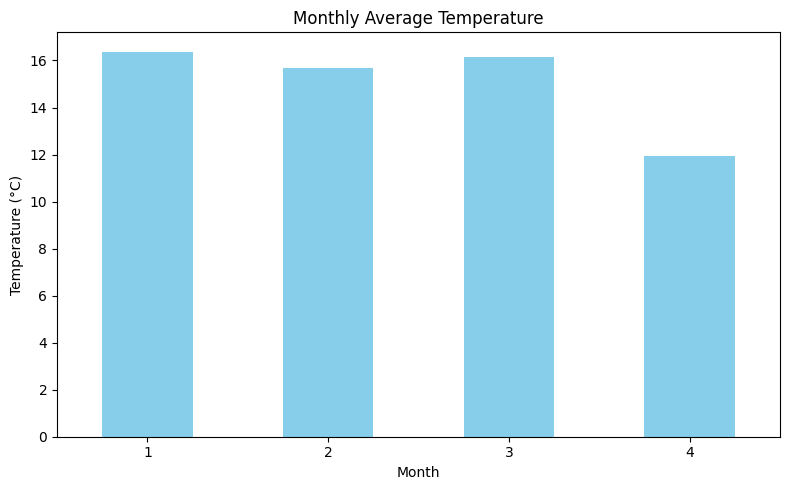

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
num_rows = 100
dates = pd.to_datetime(pd.date_range(start='2023-01-01', periods=num_rows, freq='D'))
temperatures = np.random.uniform(low=0, high=30, size=num_rows)
humidity = np.random.uniform(low=40, high=100, size=num_rows)
wind_speed = np.random.uniform(low=0, high=20, size=num_rows)
rainfall = np.random.uniform(low=0, high=10, size=num_rows)
dummy_df = pd.DataFrame({
    'Date': dates.strftime('%d-%m-%Y'),
    'Temperature (°C)': temperatures,
    'Humidity (%)': humidity,
    'Wind Speed (km/h)': wind_speed,
    'Rainfall (mm)': rainfall
})
dummy_df.to_csv('weather_data.csv', index=False)
file_path = 'weather_data.csv'
df = pd.read_csv(file_path)
print("Initial Data:")
print(df.head())
print("\nMissing Values:")
print(df.isnull().sum())
df['Temperature (°C)'] = df['Temperature (°C)'].fillna(df['Temperature (°C)'].mean())
df['Humidity (%)'] = df['Humidity (%)'].fillna(df['Humidity (%)'].mean())
df['Wind Speed (km/h)'] = df['Wind Speed (km/h)'].fillna(df['Wind Speed (km/h)'].mean())
df['Rainfall (mm)'] = df['Rainfall (mm)'].fillna(df['Rainfall (mm)'].mean())
df['Date'] = pd.to_datetime(df['Date'], format='%d-%m-%Y')
# Extract month
df['Month'] = df['Date'].dt.month

# Group by month and calculate average temperature
monthly_avg_temp = df.groupby('Month')['Temperature (°C)'].mean()

print("\nMonthly Average Temperature:")
print(monthly_avg_temp)

# -------------------------------
# c. Visualization (Bar Plot)
# -------------------------------
plt.figure(figsize=(8, 5))
monthly_avg_temp.plot(kind='bar', color='skyblue')

plt.title('Monthly Average Temperature')
plt.xlabel('Month')
plt.ylabel('Temperature (°C)')
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()